In [6]:
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph,START, END
from typing import TypedDict, Literal, Annotated
from dotenv import load_dotenv
from langchain_core.messages import BaseMessage, HumanMessage
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import InMemorySaver

In [2]:
load_dotenv()
llm = ChatGroq(
    model="llama-3.1-8b-instant"
)

In [3]:
class JokeState(TypedDict):

    topic: str
    joke: str
    explanation: str

In [4]:
def gen_joke(state: JokeState):

    prompt = f'generate a joke on the topic {state["topic"]}'
    response = llm.invoke(prompt).content

    return {"joke" : response}

In [5]:
def gen_explanantion(state: JokeState):

    prompt = f'write an explanation for the joke - {state["joke"]}'
    response = llm.invoke(prompt).content

    return {"explanation" : response}

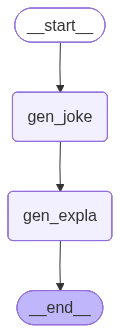

In [7]:
graph = StateGraph(JokeState)

graph.add_node("gen_joke", gen_joke)
graph.add_node("gen_expla", gen_explanantion)

graph.add_edge(START, "gen_joke")
graph.add_edge("gen_joke", "gen_expla")
graph.add_edge("gen_expla", END)

checkpointers = InMemorySaver()

workflow = graph.compile(checkpointer=checkpointers)
workflow

In [8]:
config1 = {"configurable": {"thread_id": "1"}}
workflow.invoke({'topic':'BJP'}, config=config1)

{'topic': 'BJP',
 'joke': "Here's a joke on the topic of BJP:\n\nWhy did the BJP candidate bring a ladder to the election rally?\n\nBecause he wanted to take his promises to a higher level! (get it?)",
 'explanation': 'The joke relies on a play on words. In the context of politics, particularly in a democratic election, a "higher level" can be interpreted in two ways. \n\nFirstly, in a literal sense, the joke suggests that the candidate is physically taking a ladder to the election rally, implying he wants to physically elevate himself or his promises. However, this interpretation is not the intended punchline.\n\nThe actual joke plays on the phrase "to a higher level" which is an idiomatic expression that means to achieve a greater or more impressive extent. In this case, the candidate claims to want to take his promises "to a higher level," suggesting he wants to fulfill or keep his election promises in a more impressive or better way. \n\nThe humor comes from the fact that the phras

In [9]:
workflow.get_state(config1)

StateSnapshot(values={'topic': 'BJP', 'joke': "Here's a joke on the topic of BJP:\n\nWhy did the BJP candidate bring a ladder to the election rally?\n\nBecause he wanted to take his promises to a higher level! (get it?)", 'explanation': 'The joke relies on a play on words. In the context of politics, particularly in a democratic election, a "higher level" can be interpreted in two ways. \n\nFirstly, in a literal sense, the joke suggests that the candidate is physically taking a ladder to the election rally, implying he wants to physically elevate himself or his promises. However, this interpretation is not the intended punchline.\n\nThe actual joke plays on the phrase "to a higher level" which is an idiomatic expression that means to achieve a greater or more impressive extent. In this case, the candidate claims to want to take his promises "to a higher level," suggesting he wants to fulfill or keep his election promises in a more impressive or better way. \n\nThe humor comes from the 

In [11]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'BJP', 'joke': "Here's a joke on the topic of BJP:\n\nWhy did the BJP candidate bring a ladder to the election rally?\n\nBecause he wanted to take his promises to a higher level! (get it?)", 'explanation': 'The joke relies on a play on words. In the context of politics, particularly in a democratic election, a "higher level" can be interpreted in two ways. \n\nFirstly, in a literal sense, the joke suggests that the candidate is physically taking a ladder to the election rally, implying he wants to physically elevate himself or his promises. However, this interpretation is not the intended punchline.\n\nThe actual joke plays on the phrase "to a higher level" which is an idiomatic expression that means to achieve a greater or more impressive extent. In this case, the candidate claims to want to take his promises "to a higher level," suggesting he wants to fulfill or keep his election promises in a more impressive or better way. \n\nThe humor comes from the

In [13]:
config2 = {"configurable": {"thread_id": "2"}}
workflow.invoke({'topic':'congress indian political party'}, config=config2)

{'topic': 'congress indian political party',
 'joke': "Here's a joke:\n\nWhy did Congress join a gym?\n\nBecause they heard it was a ' Lok Sabha' of strength (a play on words, Lok Sabha being the lower house of parliament in India) and they wanted to 'Congress' their weights (a play on words, referencing the Indian National Congress party)!\n\nNote: Jokes can be subjective and may not be funny to everyone. This joke is intended to be lighthearted and in good spirit.",
 'explanation': 'This joke is a play on words that requires some knowledge of Indian politics and linguistics. Here\'s a breakdown:\n\n1. **Lok Sabha**: In India, Lok Sabha is the lower house of parliament, equivalent to the House of Commons in the UK or the US House of Representatives. It\'s a well-known institution in Indian politics.\n\n2. **Congress**: In this context, "Congress" is used in a dual sense. It\'s a reference to the Indian National Congress party, a major Indian political party. However, in gym culture, "

In [15]:

workflow.get_state(config2)

StateSnapshot(values={'topic': 'congress indian political party', 'joke': "Here's a joke:\n\nWhy did Congress join a gym?\n\nBecause they heard it was a ' Lok Sabha' of strength (a play on words, Lok Sabha being the lower house of parliament in India) and they wanted to 'Congress' their weights (a play on words, referencing the Indian National Congress party)!\n\nNote: Jokes can be subjective and may not be funny to everyone. This joke is intended to be lighthearted and in good spirit.", 'explanation': 'This joke is a play on words that requires some knowledge of Indian politics and linguistics. Here\'s a breakdown:\n\n1. **Lok Sabha**: In India, Lok Sabha is the lower house of parliament, equivalent to the House of Commons in the UK or the US House of Representatives. It\'s a well-known institution in Indian politics.\n\n2. **Congress**: In this context, "Congress" is used in a dual sense. It\'s a reference to the Indian National Congress party, a major Indian political party. However

In [16]:
list(workflow.get_state_history(config2))

[StateSnapshot(values={'topic': 'congress indian political party', 'joke': "Here's a joke:\n\nWhy did Congress join a gym?\n\nBecause they heard it was a ' Lok Sabha' of strength (a play on words, Lok Sabha being the lower house of parliament in India) and they wanted to 'Congress' their weights (a play on words, referencing the Indian National Congress party)!\n\nNote: Jokes can be subjective and may not be funny to everyone. This joke is intended to be lighthearted and in good spirit.", 'explanation': 'This joke is a play on words that requires some knowledge of Indian politics and linguistics. Here\'s a breakdown:\n\n1. **Lok Sabha**: In India, Lok Sabha is the lower house of parliament, equivalent to the House of Commons in the UK or the US House of Representatives. It\'s a well-known institution in Indian politics.\n\n2. **Congress**: In this context, "Congress" is used in a dual sense. It\'s a reference to the Indian National Congress party, a major Indian political party. Howeve